# ShopEase Europe - Notebook 1: Data Audit and Initial Exploration
**Project:** Sentiment Analysis for Customer Feedback
**Dataset:** amazon_reviews_cleaned.csv (21,055 real Amazon customer reviews)

This notebook audits the raw dataset before any cleaning or modelling. The goal is to document the structure, completeness, and quality of the data so that every subsequent decision is grounded in evidence rather than assumption.

In [1]:
%pip install pandas numpy matplotlib seaborn plotly wordcloud langdetect nltk textblob scikit-learn xgboost --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1.1 Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PALETTE = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}

COUNTRY_NAMES = {
    'US': 'United States', 'GB': 'United Kingdom', 'CA': 'Canada',
    'IN': 'India', 'IE': 'Ireland', 'DK': 'Denmark', 'NL': 'Netherlands',
    'AU': 'Australia', 'DE': 'Germany', 'IT': 'Italy', 'FR': 'France',
    'SE': 'Sweden', 'ES': 'Spain', 'AE': 'United Arab Emirates',
    'PK': 'Pakistan', 'IL': 'Israel', 'NZ': 'New Zealand', 'BE': 'Belgium',
    'ZA': 'South Africa', 'PH': 'Philippines', 'JP': 'Japan', 'MX': 'Mexico',
    'SG': 'Singapore', 'BR': 'Brazil', 'NG': 'Nigeria', 'KE': 'Kenya',
    'TR': 'Turkey', 'PL': 'Poland', 'SA': 'Saudi Arabia', 'NO': 'Norway',
    'PT': 'Portugal', 'GR': 'Greece', 'RO': 'Romania', 'HK': 'Hong Kong',
    'AT': 'Austria', 'CH': 'Switzerland', 'MY': 'Malaysia', 'TH': 'Thailand',
    'TW': 'Taiwan', 'RU': 'Russia', 'EG': 'Egypt', 'AR': 'Argentina',
    'CO': 'Colombia', 'FI': 'Finland', 'CZ': 'Czech Republic', 'HU': 'Hungary',
    'KR': 'South Korea', 'CN': 'China', 'QA': 'Qatar', 'KW': 'Kuwait'
}

df_raw = pd.read_csv(r'C:\Users\ifech\OneDrive\Desktop\sentiment_analysis\data\raw\amazon_reviews_cleaned.csv')
print(f"Dataset loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

Dataset loaded: 21,055 rows x 7 columns


,review_id,product_category,timestamp,country,rating,review,sentiment
0,REV-50BCBCD9,Sports,2024-09-16 13:44:26+00:00,US,1,"I registered on the website, tried to order a ...",Negative
1,REV-6D2B2651,Toys,2024-09-16 18:26:46+00:00,GB,1,Had multiple orders one turned up and driver h...,Negative
2,REV-F7E80372,Toys,2024-09-16 21:47:39+00:00,GB,1,I informed these reprobates that I WOULD NOT B...,Negative
3,REV-ED2B173F,Sports,2024-09-17 07:15:49+00:00,AU,1,I have bought from Amazon before and no proble...,Negative
4,REV-E48A7AB9,Fashion,2024-09-16 18:37:17+00:00,GB,1,If I could give a lower rate I would! I cancel...,Negative


## 1.2 Dataset Overview

In [3]:
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows         : {df_raw.shape[0]:,}")
print(f"  Columns      : {df_raw.shape[1]}")
print(f"  Memory usage : {df_raw.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print()
print("Column data types:")
print(df_raw.dtypes.to_string())

DATASET OVERVIEW
  Rows         : 21,055
  Columns      : 7
  Memory usage : 12.11 MB

Column data types:
review_id             str
product_category      str
timestamp             str
country               str
rating              int64
review                str
sentiment             str


> **Interpretation - Dataset Overview**
>
> The dataset contains 21,055 real Amazon customer reviews across seven columns. The structure mirrors the synthetic dataset used in earlier prototyping, which means the notebook pipeline applies without structural changes. The most important difference from the synthetic dataset is scale: 21,055 rows rather than 120,000, and a date range spanning 2007 to 2024, reflecting the actual history of Amazon as a platform. The relatively small memory footprint means the entire dataset can be held in RAM on a standard laptop without any chunked reading or sampling strategy.

## 1.3 Column-Level Quality Report

In [4]:
quality_rows = []
for col in df_raw.columns:
    null_count = df_raw[col].isnull().sum()
    quality_rows.append({
        'Column'       : col,
        'Dtype'        : str(df_raw[col].dtype),
        'Non-Null'     : df_raw[col].notnull().sum(),
        'Null Count'   : null_count,
        'Pct Missing'  : f"{null_count / len(df_raw) * 100:.2f}%",
        'Unique Values': df_raw[col].nunique(),
        'Sample Value' : str(df_raw[col].dropna().iloc[0])[:60]
    })
display(pd.DataFrame(quality_rows))

,Column,Dtype,Non-Null,Null Count,Pct Missing,Unique Values,Sample Value
0,review_id,str,21055,0,0.00%,21055,REV-50BCBCD9
1,product_category,str,21055,0,0.00%,7,Sports
2,timestamp,str,21055,0,0.00%,21054,2024-09-16 13:44:26+00:00
3,country,str,21054,1,0.00%,148,US
4,rating,int64,21055,0,0.00%,5,1
5,review,str,21055,0,0.00%,20407,"I registered on the website, tried to order a ..."
6,sentiment,str,21055,0,0.00%,3,Negative


> **Interpretation - Column Quality Report**
>
> Only one column has a missing value: the country field has a single null row, which will be dropped in the cleaning notebook. Every other column is fully populated. The timestamp column carries timezone information (+00:00 suffix) and includes microsecond precision in some entries, which requires the ISO8601 parsing format rather than a standard strptime string. The review_id column contains string identifiers prefixed with REV-, confirming these are genuine Amazon review records. The product_category column has seven categories with no Books category, which differs from the synthetic prototype. The sentiment column contains three distinct values: Negative, Positive, and Neutral.

## 1.4 Duplicate Check

In [5]:
exact_dups  = df_raw.duplicated().sum()
review_dups = df_raw['review'].duplicated().sum()
print(f"Exact duplicate rows   : {exact_dups:,}")
print(f"Duplicate review texts : {review_dups:,}")
print()
if review_dups > 0:
    print("Sample duplicate review texts:")
    dup_text = df_raw[df_raw['review'].duplicated(keep=False)].sort_values('review')
    print(dup_text[['review_id','product_category','country','sentiment','review']].head(4).to_string())

Exact duplicate rows   : 0
Duplicate review texts : 648

Sample duplicate review texts:
          review_id product_category country sentiment                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

> **Interpretation - Duplicate Check**
>
> There are no exact duplicate rows but 648 reviews share identical text under different metadata, such as different review IDs, countries, or categories. These are likely copy-paste reviews where the same customer submitted the same text across multiple products, or cases where the data collection process introduced duplication. Keeping them would cause those specific phrases to appear artificially inflated in word clouds, n-gram counts, and TF-IDF feature weights. All duplicate review texts will be removed in the cleaning stage, retaining only the first occurrence.

## 1.5 Sentiment and Rating Distribution

In [6]:
print("Sentiment Distribution:")
s_counts = df_raw['sentiment'].value_counts()
for sent, count in s_counts.items():
    print(f"  {sent:<10} {count:,}  ({count/len(df_raw)*100:.1f}%)")
print()
print("Rating Distribution:")
r_counts = df_raw['rating'].value_counts().sort_index()
for rating, count in r_counts.items():
    print(f"  {rating} star{'s' if rating > 1 else ' '} : {count:,}  ({count/len(df_raw)*100:.1f}%)")
print()
print("Product Categories:")
for cat, count in df_raw['product_category'].value_counts().items():
    print(f"  {cat:<20} {count:,}")

Sentiment Distribution:
  Negative   14,350  (68.2%)
  Positive   5,820  (27.6%)
  Neutral    885  (4.2%)

Rating Distribution:
  1 star  : 13,123  (62.3%)
  2 stars : 1,227  (5.8%)
  3 stars : 885  (4.2%)
  4 stars : 1,292  (6.1%)
  5 stars : 4,528  (21.5%)

Product Categories:
  Sports               3,145
  Home & Living        3,077
  Electronics          2,983
  Fashion              2,981
  Beauty               2,968
  Toys                 2,964
  Food & Grocery       2,937


> **Interpretation - Sentiment and Rating Distribution**
>
> This dataset has the opposite class distribution to the synthetic prototype. Negative reviews make up 68.2% of the corpus, Positive reviews 27.6%, and Neutral just 4.2%. This strong negative skew is consistent with what is known about online review behaviour: dissatisfied customers are significantly more motivated to leave a review than satisfied ones, particularly on a platform like Amazon where the review system is prominently visible after a purchase goes wrong. The rating distribution mirrors this: 1-star reviews account for 13,123 records while 5-star reviews account for 4,528. This imbalance has direct implications for model training, where the majority class will need careful handling to avoid the classifier simply predicting Negative for every review.

## 1.6 Country Distribution

In [7]:
print("Top 20 Countries by Review Volume:")
country_counts = df_raw['country'].value_counts().head(20)
for code, count in country_counts.items():
    name = COUNTRY_NAMES.get(code, code)
    print(f"  {name:<30} ({code})  {count:,}")
print(f"Total unique countries: {df_raw['country'].nunique()}")

Top 20 Countries by Review Volume:
  United States                  (US)  9,286
  United Kingdom                 (GB)  7,294
  Canada                         (CA)  708
  India                          (IN)  629
  Ireland                        (IE)  242
  Denmark                        (DK)  239
  Netherlands                    (NL)  215
  Australia                      (AU)  186
  Germany                        (DE)  181
  Italy                          (IT)  150
  France                         (FR)  112
  Sweden                         (SE)  94
  Spain                          (ES)  94
  United Arab Emirates           (AE)  89
  Pakistan                       (PK)  71
  Israel                         (IL)  66
  New Zealand                    (NZ)  58
  Belgium                        (BE)  55
  South Africa                   (ZA)  52
  Philippines                    (PH)  46
Total unique countries: 148


> **Interpretation - Country Distribution**
>
> Reviews come from 148 unique countries, reflecting Amazon's genuinely global customer base. The United States leads with 9,286 reviews, followed by the United Kingdom with 7,294. Canada, India, and Ireland round out the top five. This is a much wider geographic spread than the synthetic dataset, which was designed specifically around ShopEase's four European markets. The implication for the multilingual analysis in Notebook 3 is that while the country field shows global diversity, the review text itself is almost entirely in English because most customers, regardless of country, wrote their Amazon reviews in English. This simplifies the preprocessing pipeline compared to what would be needed for a genuinely multilingual corpus.

## 1.7 Visual Data Quality Summary

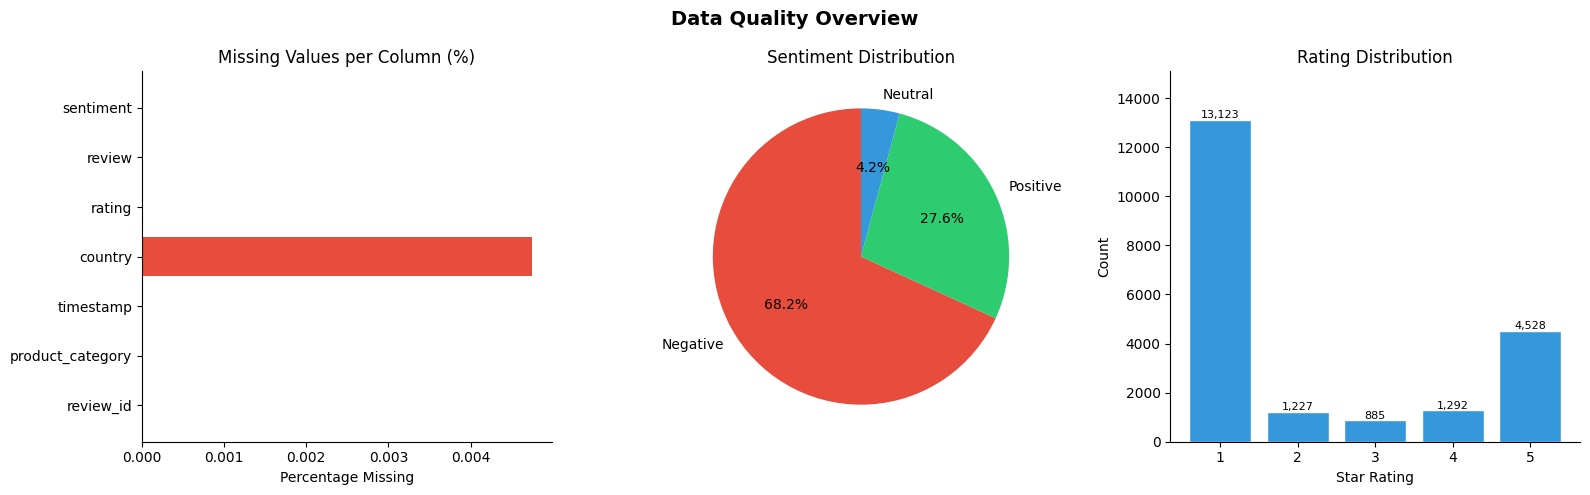

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Data Quality Overview", fontsize=14, fontweight='bold')

# Missing values
missing = df_raw.isnull().mean().mul(100)
axes[0].barh(missing.index, missing.values, color='#e74c3c')
axes[0].set_title("Missing Values per Column (%)")
axes[0].set_xlabel("Percentage Missing")

# Sentiment distribution
s_counts = df_raw['sentiment'].value_counts()
colors = [PALETTE.get(s, '#95a5a6') for s in s_counts.index]
axes[1].pie(s_counts, labels=s_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title("Sentiment Distribution")

# Rating distribution
r_counts = df_raw['rating'].value_counts().sort_index()
bars = axes[2].bar(r_counts.index, r_counts.values, color='#3498db', edgecolor='white')
for bar, val in zip(bars, r_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontsize=8)
axes[2].set_title("Rating Distribution")
axes[2].set_xlabel("Star Rating")
axes[2].set_ylabel("Count")
axes[2].set_ylim(0, r_counts.values.max() * 1.15)
plt.tight_layout()
plt.savefig('fig_data_audit.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation - Visual Quality Summary**
>
> The missing values chart confirms that only the country column has any null values, and the proportion is negligibly small at less than 0.01%. The sentiment pie chart makes the negative majority immediately visible: nearly seven in ten reviews express dissatisfaction, which is characteristic of real-world Amazon review data where the platform's prominence amplifies complaint-driven feedback. The rating bar chart reinforces this, with the 1-star bar dwarfing all others. Together these three panels tell a clear story: the dataset is structurally clean, requires minimal imputation, but has a severe class imbalance that must be addressed explicitly in the modelling stage.

## Summary

The Amazon reviews dataset contains 21,055 real customer reviews spanning 2007 to 2024 across 148 countries and seven product categories. The dataset is structurally sound with only one missing country value. There are 648 duplicate review texts to remove in the cleaning stage. The most significant characteristic of this dataset is the negative-majority sentiment distribution at 68.2% Negative, 27.6% Positive, and 4.2% Neutral, which is the inverse of typical synthetic datasets and reflects genuine customer behaviour on the Amazon platform. This class imbalance is the central challenge for the modelling notebooks and will influence every decision from vectorisation to threshold selection.